In [49]:
import pandas as pd
import numpy as np

df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
pd.options.display.float_format = '{:,.2f}'.format
df['amount'].describe()






count              93.00
mean      234,919,452.42
std     1,455,606,409.02
min           -50,000.00
25%         4,899,627.00
50%        20,690,823.00
75%        36,277,731.00
max     9,999,999,999.99
Name: amount, dtype: float64

In [50]:
print(f"Mean:    ${df['amount'].mean():>20,.2f}")
print(f"Median : ${df['amount'].median():>20,.2f}")
print(f"Mode :   ${df['amount'].mode()[0]:>20,.2f}")

Mean:    $      234,919,452.42
Median : $       20,690,823.00
Mode :   $           -1,000.00


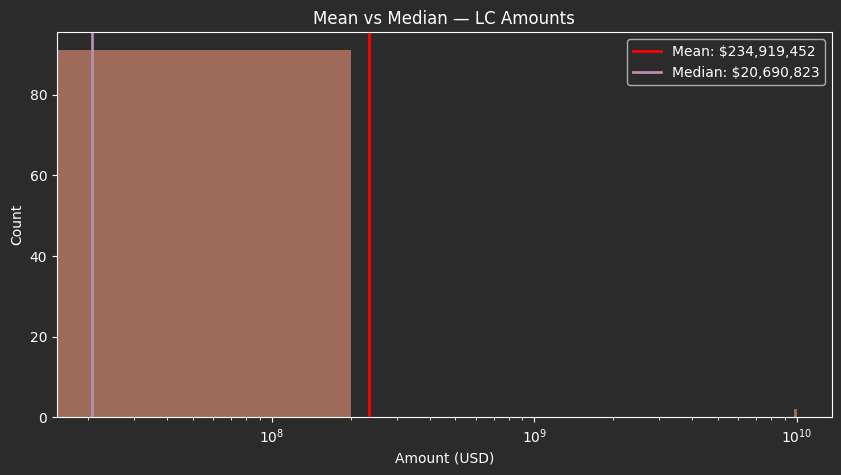

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['amount'].dropna(), bins=50, color='#D08770', alpha=0.7)
ax.axvline(df['amount'].mean(), color='red', linewidth=2, label=f"Mean: ${df['amount'].mean():,.0f}")
ax.axvline(df['amount'].median(), color='#B48EAD', linewidth=2, label=f"Median: ${df['amount'].median():,.0f}")

ax.set_title('Mean vs Median — LC Amounts')
ax.set_xlabel('Amount (USD)')
ax.set_ylabel('Count')
ax.set_xscale('log')

ax.legend()

plt.show()

In [52]:
df['amount'].value_counts().head(10)

amount
-1,000.00           8
-50,000.00          3
0.00                3
0.00                2
9,999,999,999.99    2
12,537,943.00       1
31,025,296.00       1
37,125,991.00       1
14,155,946.00       1
5,457,531.00        1
Name: count, dtype: int64

In [53]:
df['currency'].mode()[0]  # [0] -. birden fazla mode olursa



'JPY'

In [54]:
df['amount'].mode()

0   -1,000.00
Name: amount, dtype: float64

Mean → outlier'a teslim olur

Median → gerçeği söyler

Mode → tekrar tespiti, kategorisel veri

Variance ve Std Dev

In [55]:
print(f"Variance: ${df['amount'].var():>25,.2f}")
print(f"Std Dev:  ${df['amount'].std():>25,.2f}")

Variance: $2,118,790,017,967,659,520.00
Std Dev:  $         1,455,606,409.02


In [57]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['amount'] < lower_bound) | (df['amount'] > upper_bound)]

print(f"IQR: ${IQR:,.2f}")
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")
print(f"Outlier count: {len(outliers)}")

print(outliers['amount'].values)

IQR: $31,378,104.00
Lower bound: $-42,167,529.00
Upper bound: $83,344,887.00
Outlier count: 2
[1.e+10 1.e+10]


Saved → data/output/boxplot_amounts.png


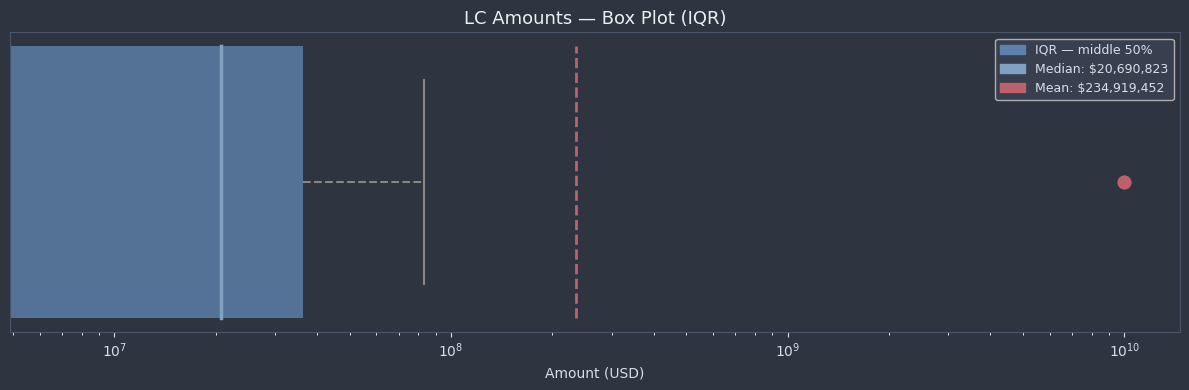

In [59]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

df = pd.read_csv('../../data/output/validation_report.csv')
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
median = df['amount'].median()
mean = df['amount'].mean()
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_facecolor('#2E3440')
fig.patch.set_facecolor('#2E3440')

# box
ax.barh(0, Q3 - Q1, left=Q1, height=0.4, color='#5E81AC', alpha=0.8)
# whiskers
ax.plot([lower_bound, Q1], [0, 0], color='#888780', linewidth=1.5, linestyle='--')
ax.plot([Q3, upper_bound], [0, 0], color='#888780', linewidth=1.5, linestyle='--')
ax.plot([lower_bound, lower_bound], [-0.15, 0.15], color='#888780', linewidth=1.5)
ax.plot([upper_bound, upper_bound], [-0.15, 0.15], color='#888780', linewidth=1.5)
# median
ax.plot([median, median], [-0.2, 0.2], color='#81A1C1', linewidth=2.5)
# mean
ax.plot([mean, mean], [-0.2, 0.2], color='#BF616A', linewidth=2, linestyle='--')
# outliers
outliers = df[df['amount'] > upper_bound]['amount']
ax.scatter(outliers, [0]*len(outliers), color='#BF616A', zorder=5, s=80)

ax.set_yticks([])
ax.tick_params(colors='#D8DEE9')
ax.xaxis.label.set_color('#D8DEE9')
for spine in ax.spines.values():
    spine.set_edgecolor('#4C566A')
ax.set_xscale('log')
ax.set_xlabel('Amount (USD)', color='#D8DEE9')
ax.set_title('LC Amounts — Box Plot (IQR)', color='#ECEFF4', fontsize=13)

legend = [
    mpatches.Patch(color='#5E81AC', label='IQR — middle 50%'),
    mpatches.Patch(color='#81A1C1', label=f'Median: ${median:,.0f}'),
    mpatches.Patch(color='#BF616A', label=f'Mean: ${mean:,.0f}'),
]
ax.legend(handles=legend, facecolor='#3B4252', labelcolor='#D8DEE9', fontsize=9)

plt.tight_layout()
plt.savefig('../../data/output/boxplot_amounts.png', dpi=150, bbox_inches='tight')
print("Saved → data/output/boxplot_amounts.png")

In [60]:
q1 = df['amount'].quantile(0.25)
q3 = df['amount'].quantile(0.75)

below_q1 = (df['amount'] < q1).sum()
in_iqr = ((df['amount'] >= q1) & (df['amount'] <= q3)).sum()
above_q3 = (df['amount'] > q3).sum()

print(f"Q1 altı:  {below_q1}")
print(f"IQR içi:  {in_iqr}")
print(f"Q3 üstü:  {above_q3}")

Q1 altı:  23
IQR içi:  47
Q3 üstü:  23
